# Estimation of a padel play heatmap based on player pose tracking using YOLO26 

Object tracking methods have been a staple for the development of sports analytics in racket sports, allowing for the extraction of player positions and movements during matches. In this study, we propose a novel approach to estimate a padel play heatmap by leveraging player pose tracking using the YOLO26 object detection model.

## 1. The Game

Tracking player movement in a padel game has a particular drawback, because right now most premier padel games are played in an indoor court, the lighting of the facility usually makes the court glass walls reflective, which can create challenges for traditional tracking methods. In the other hand, outdoor padel games have better lighting conditions, but the light makes the background of the court, which is usually occupied by spectators, more complex and noisy for tracking algorithms.

Because of this we decided to select a play of a particular game which had nearly ideal conditions, the 2024 World Championship game 2 which faced Juan Lebrón and Ale Galán against Federico Chingotto and Agustín Tapia. The game was played in an outdoor court with good lighting conditions and a relatively simple background, making it suitable for our analysis.

You can watch the full game here:
https://www.youtube.com/watch?v=oxVDX7lMwhg

## 2. Methodology
### 2.1 Player Pose Tracking with YOLO26

In order to track the players' positions and movements, we utilized YOLO26, a state-of-the-art object detection model that is capable of detecting and localizing players in real-time.

We use the YOLO26 pose estimation model to detect 17 keypoints of each player, which include the head, shoulders, elbows, wrists, hips, knees, and ankles. We extracted these keypoints into a CSV file for the creation of the heatmap.



In [1]:
import cv2
import csv
from ultralytics import YOLO
from ultralytics import solutions
from ultralytics.utils.downloads import safe_download
import pandas as pd

model = YOLO("yolo26n-pose.pt")

results = model.track(source=r"C:\Padel_Project\video1.mp4", show = True, save = True, project=r"C:\Padel_Project\results",
    name="tracking_lebron", persist= True,  imgsz = 1920, conf = 0.05, tracker= r"C:\Padel_Project\custom_botsort.yaml")

KeyboardInterrupt: 

While using this model we faced a major challenge, the tracking system had difficulties in detecting the players which were far away from the camera, in order to overcome this we had to change the baseline setting of the `botsort.yaml` tracking configuration file to increase the detection threshold and reduce false positives.

The next code snippet shows the configuration changes made to the `botsort.yaml` file, we changed the track_buffer from 30 to 90 to allow tracks to persist longer when detections are temporarily missed. We also increased the detection confidence threshold from 0.5 to 0.7 so that only higher-confidence detections were considered for tracking.

In [ ]:
tracker_type: botsort # (str) Tracker backend: botsort
track_high_thresh: 0.25 # (float) First-stage match threshold; raise for cleaner tracks, lower to keep more
track_low_thresh: 0.1 # (float) Second-stage threshold for low-score matches; balances recovery vs drift
new_track_thresh: 0.25 # (float) Start a new track if no match ≥ this; higher reduces false tracks
track_buffer: 90 # (int) Frames to keep lost tracks alive; higher handles occlusion, increases ID switches risk
match_thresh: 0.7 # (float) Association similarity threshold (IoU/cost); tune with detector quality
fuse_score: True # (bool) Fuse detection score with motion/IoU for matching; stabilizes weak detections

# BoT-SORT specifics
gmc_method: sparseOptFlow # (str) Global motion compensation: sparseOptFlow|orb|sift|ecc|none; helps moving camera scenes

# ReID model related thresh
proximity_thresh: 0.5 # (float) Min IoU to consider tracks proximate for ReID; higher is stricter
appearance_thresh: 0.8 # (float) Min appearance similarity for ReID; raise to avoid identity swaps
with_reid: False # (bool) Enable ReID model use; needs extra model and compute
model: auto # (str) ReID model name/path; "auto" uses detector features if available

Even though these changes improved the tracking performance, we still encountered some challenges with occlusions, for example the ID tracker of a player changed two times during the game but we were able to manually correct the IDs in the CSV file to ensure accurate tracking data.

### 2.2 Heatmap Generation
After obtaining the player positions from the pose tracking, we proceeded to generate a heatmap that visualizes the areas of the court where players spent the most time.

First, we took the ankle keypoints of each player as they are the most representative of the player's position on the court and we grouped the data by player ID and frame number.

Next, we calculated the confidence-weighted average of the two ankle x-coordinates and y-coordinates. In this way we can obtain a representative foot position for each player in each frame. These positions are the used to determine where players spend their most time on the court.

In [4]:
import pandas as pd
import numpy as np
import cv2
from pandas.core import groupby
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch



df = pd.read_csv(r"C:\Padel_Project\results\players_keypoints.csv")

ankle_point = df[(df["keypoint_id"] == 15) | (df["keypoint_id"] == 16)]
combination = ankle_point.groupby(["player_id", "frame"])

X_feet = combination.apply(lambda group: np.average(group["x"], weights=group["conf"]))
Y_feet = combination.apply(lambda group: np.average(group["y"], weights=group["conf"]))

feet_positions = pd.DataFrame({
    "x": X_feet,
    "y": Y_feet
}).reset_index()

#### 2.2.1 Homography

We have said before that we took the representative foot position of each player in each frame, but that does not mean that the image coordinates are in the same coordinate system as the court. In order to map the player positions to the court coordinates, we applied a homography transformation.

The homography matrix was calculated from corresponding reference points in the image and court coordinate systems. This matrix was then applied to the representative foot position of every player in each frame, transforming their pixel coordinates into corresponding court coordinates for use in the heatmap. The resulting coordinates were subsequently used to generate the heatmap.



In [5]:
# Homography 

image_points = np.float32([
    [582, 325],    # Top-left
    [1390, 325],   # Top-right
    [214, 958],    # Bottom-left
    [1715, 958],    # Bottom-right

    # Net line (meets side walls)
    [450, 450],      # Net - left post
    [1483, 450],     # Net - right post

    # Far service line (near the back/far baseline, y=0)
    [548, 382],    # Far service line - left sideline intersection
    [1387, 382],   # Far service line - right sideline intersection
    [965, 382],    # Far service line - center T
    
    # Near service line (near the front/camera baseline, y=20)
    [310, 796],   # Near service line - left sideline intersection
    [1622, 796],  # Near service line - right sideline intersection
    [964, 796],   # Near service line - center T


])


court_points = np.float32([
    # Original 4 corners
    [0, 0],       # Back-left corner
    [10, 0],      # Back-right corner
    [0, 20],      # Front-left corner
    [10, 20],     # Front-right corner

    # Net line (meets side walls)
    [0, 10],      # Net - left post
    [10, 10],     # Net - right post

    # Far service line (near the back/far baseline, y=0)
    [0, 3.05],    # Far service line - left sideline intersection
    [10, 3.05],   # Far service line - right sideline intersection
    [5, 3.05],    # Far service line - center T

    # Near service line (near the front/camera baseline, y=20)
    [0, 16.95],   # Near service line - left sideline intersection
    [10, 16.95],  # Near service line - right sideline intersection
    [5, 16.95],   # Near service line - center T
])


H, status = cv2.findHomography(
    image_points,
    court_points
)

# Extract image coordinates
points = feet_positions[["x", "y"]].values.astype(np.float32)

# Transform into court coordinates
court_positions = cv2.perspectiveTransform(
    points.reshape(-1, 1, 2),
    H
).reshape(-1, 2)

# Add transformed coordinates
feet_positions["court_x"] = court_positions[:, 0]
feet_positions["court_y"] = court_positions[:, 1]


#### 2.2.2 Heatmap Visualization

Finally we used the transformed court coordinates to create a heatmap that visualizes the areas of the court where players spent the most time. 

First, the court was defined as a 10 x 20 coordinate system (standard padel court dimensions) corresponding to the width and length of the court. We then divided this area into a grid of 200 x 400 cells, creating a high-resolution grid that allows for detailed visualization of player movement. 

For each player, we extracted their transformed court_x and court_y coordinates and removed any invalid or non-finite values. We also removed coordinates that fell outside the boundaries of the court (sometimes in padel games players do get out of the court but for this particular example that did not happen).

The valid positions were then converted into a two-dimensional histogram using `np.histogram2d()`. This divides the court into the predefined grid cells and counts how many player positions fall within each cell. Consequently, cells containing a larger number of player positions represent areas where the player was located more frequently.

To obtain a smoother representation of player positioning, a Gaussian filter with a sigma of 8 was applied to the resulting histogram. We then normalized the resulting heatmap by dividing all values by the maximum value for that player and we plotted the normalized heatmaps using `contourf()` with a different color map assigned to each player.

We also drew the court lines on the heatmap to provide context for the player positions.

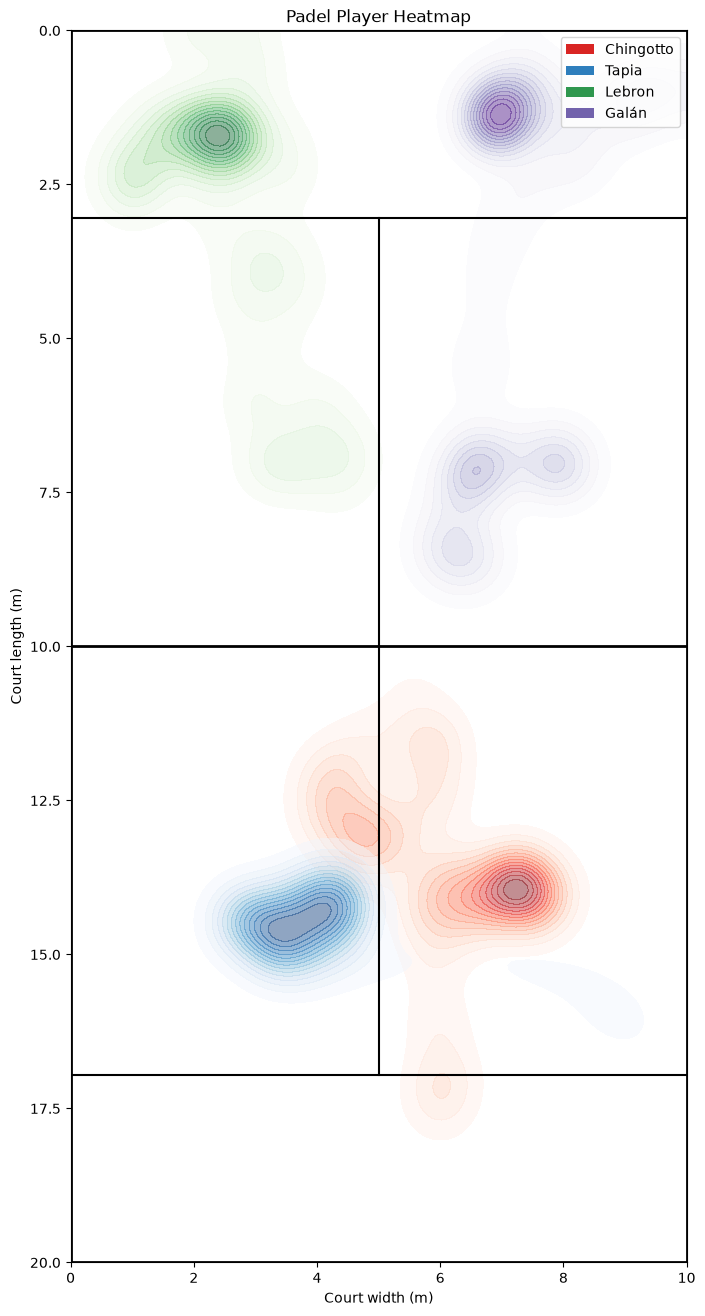

In [8]:
# Court dimensions 

court_width = 10
court_length = 20

# Grid for the heatmap

nx = 200
ny = 400

x_edges = np.linspace(0, court_width, nx + 1)
y_edges = np.linspace(0, court_length, ny + 1)

x_centers = (x_edges[:-1] + x_edges[1:]) / 2
y_centers = (y_edges[:-1] + y_edges[1:]) / 2

X, Y = np.meshgrid(x_centers, y_centers)

# Player colors

player_colors = {
    1: "Reds",
    2: "Blues",
    3: "Greens",
    4: "Purples"
}

# Figure creation

fig, ax = plt.subplots(figsize=(8, 16))

# Heatmap for each player

for player_id in sorted(feet_positions["player_id"].unique()):

    player_data = feet_positions[
        feet_positions["player_id"] == player_id
    ]

    x = player_data["court_x"].to_numpy()
    y = player_data["court_y"].to_numpy()

    # Remove invalid points
    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    # Keep only points inside court
    valid = (
        (x >= 0) & (x <= court_width) &
        (y >= 0) & (y <= court_length)
    )

    x = x[valid]
    y = y[valid]

    # 2D histogram
    heatmap, _, _ = np.histogram2d(
        x,
        y,
        bins=[x_edges, y_edges]
    )

    # Transpose because histogram2d returns [x,y]
    heatmap = heatmap.T

    # Smooth the heatmap
    heatmap = gaussian_filter(
        heatmap,
        sigma=8
    )

    # Normalize this player's heatmap
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    # Plot
    ax.contourf(
        X,
        Y,
        heatmap,
        levels=np.linspace(0.05, 1, 15),
        cmap=player_colors[player_id],
        alpha=0.45
    )

# Court dimensions
court_width = 10
court_length = 20

# Outer court

ax.plot(
    [0, 10, 10, 0, 0],
    [0, 0, 20, 20, 0],
    color="black",
    linewidth=2
)

# Net

ax.plot(
    [0, 10],
    [10, 10],
    color="black",
    linewidth=2
)

# Service lines

# Near side service line
ax.plot(
    [0, 10],
    [3.05, 3.05],
    color="black",
    linewidth=1.5
)

# Far side service line
ax.plot(
    [0, 10],
    [16.95, 16.95],
    color="black",
    linewidth=1.5
)

# Center service lines

# Near side T
ax.plot(
    [5, 5],
    [3.05, 10],
    color="black",
    linewidth=1.5
)

# Far side T

ax.plot(
    [5, 5],
    [10, 16.95],
    color="black",
    linewidth=1.5
)

# Labels 

ax.set_xlim(0, 10)
ax.set_ylim(0, 20)

ax.set_aspect("equal")

ax.set_xlabel("Court width (m)")
ax.set_ylabel("Court length (m)")

ax.set_title("Padel Player Heatmap")
ax.invert_yaxis()


# Legend

player_names = {
    1: "Chingotto",
    2: "Tapia",
    3: "Lebron",
    4: "Galán"
}

legend = [
    Patch(
        facecolor=plt.get_cmap(player_colors[player_id])(0.7),
        label=player_names[player_id]
    )
    for player_id in sorted(feet_positions["player_id"].unique())
]

ax.legend(handles=legend)

plt.show()

## 3. Conclusion

Tracking methods are and for ever will be a fundamental part of racket sports analytics, and the use of YOLO26 for player pose tracking has proven to be effective in estimating player positions and movements during padel games.

This tracking methods can help us obtain valuable insights into player behavior, strategies, and performance, which can be used to improve training and match preparation.

This study is only a small part of what computer vision methods can do for racket sports, and we hope that this work will inspire further research and development in this area.